In [2]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import math

from scipy.stats import false_discovery_control

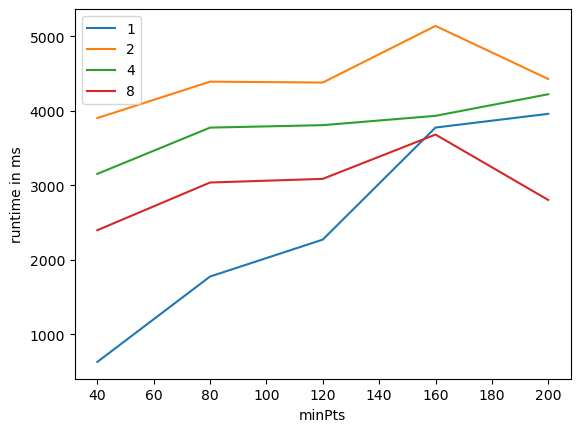

In [18]:
points_name = "results/points_densired_3.csv_eps_0.1_minPts_50.csv"
timing_name = "results/timing.csv"
bounding_name = "results/bounding_densired_3.csv_eps_0.1_minPts_50.csv"
save_directory = "diagrams/"

show_grid = False
show_bounding = False

dim = 2
set_epsilon = 0.1

Path(save_directory).mkdir(exist_ok=True)

# points_df = pd.read_csv(points_name)
timing_df = pd.read_csv(timing_name)
# xmin = points_df["x0"].min()
# xmax = points_df["x0"].max()
# ymin = points_df["x1"].min()
# ymax = points_df["x1"].max()
#
# bbs_df = pd.read_csv(bounding_name)
# bbs = []
#
# for temp_x_min in bbs_df["x0min"]:
#     if temp_x_min == "min_x0":
#         temp_x_min = xmin
#     bbs.append([float(temp_x_min)])
#
# count = 0
# for temp_x_max in bbs_df["x0max"]:
#     if temp_x_max == "max_x0":
#         temp_x_max = xmax
#     bbs[count].append(float(temp_x_max))
#     count += 1
#
# count = 0
# for temp_y_min in bbs_df["x1min"]:
#     if temp_y_min == "min_x1":
#         temp_y_min = ymin
#     bbs[count].append(float(temp_y_min))
#     count += 1
#
# count = 0
#
# for temp_y_max in bbs_df["x1max"]:
#     if temp_y_max == "max_x1":
#         temp_y_max = ymax
#     bbs[count].append(float(temp_y_max))
#     count += 1
#
# #print(bbs)
# for bb in bbs:
#     print(bb)
#
# fig,ax = plt.subplots()
#
# if show_grid:
#     step = set_epsilon/math.sqrt(dim)
#     start_x = xmin - (math.fmod(xmin, step))
#     start_y = ymin - (math.fmod(ymin, step))
#     grid_x = start_x
#     while grid_x < xmax:
#         grid_y = start_y
#         while grid_y < ymax:
#             rect = patches.Rectangle(
#                 (grid_x, grid_y), step, step,
#                 linewidth=0.5,
#                 edgecolor='gray',
#                 facecolor='none'
#             )
#             ax.add_patch(rect)
#             grid_y += step
#         grid_x += step
#
# for cluster in points_df["clusterId"].unique():
#     cluster_df = points_df[points_df["clusterId"] == cluster]
#     if cluster_df["clusterId"].unique()[0] != -1:
#         ax.scatter(cluster_df["x0"], cluster_df["x1"], s=0.1, label=str(cluster))
#     else:
#         ax.scatter(cluster_df["x0"], cluster_df["x1"], s=0.1, label=str(cluster), color='0.95')
# if show_bounding:
#     for bb in bbs:
#         x1 = bb[0]
#         x2 = bb[1]
#         y1 = bb[2]
#         y2 = bb[3]
#         width = x2-x1
#         height = y2-y1
#         rect = patches.Rectangle(
#             (x1, y1), width, height,
#             linewidth=1,
#             edgecolor='red',
#             facecolor='none'
#         )
#         ax.add_patch(rect)
# #plt.legend()
# plt.show()

runtime_df = timing_df[timing_df["dataset"] == "densired_2_shrink.csv"]
runtime_same_epsilon_df = runtime_df[runtime_df["minPts"] != 50]
runtime_same_epsilon_df.sort_values(by="minPts")
runtime_same_minPts_df = runtime_df[runtime_df["minPts"] == 50]
runtime_same_minPts_df.sort_values(by="epsilon")
#print(runtime_df)
#print(runtime_same_epsilon_df)
#print(runtime_same_minPts_df)

fig,ax = plt.subplots()
for num_proc in runtime_same_epsilon_df["numProcesses"].unique():
    proc_runtime_df = runtime_same_epsilon_df[runtime_same_epsilon_df["numProcesses"] == num_proc]
    ax.plot(proc_runtime_df["minPts"], proc_runtime_df["totalMs"], label=num_proc)
ax.set_xlabel("minPts")
ax.set_ylabel("runtime in ms")
ax.legend()
plt.show()


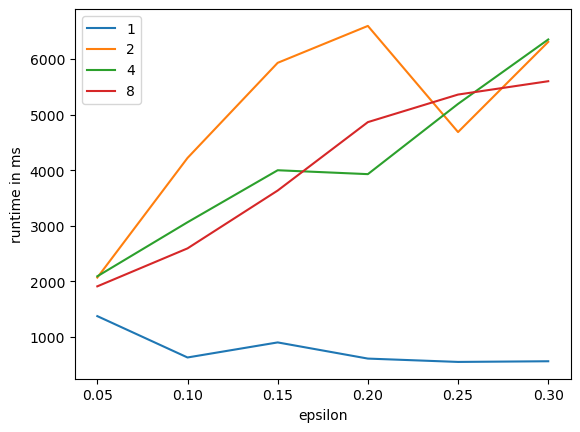

In [19]:
fig,ax = plt.subplots()
for num_proc in runtime_same_minPts_df["numProcesses"].unique():
    proc_runtime_df = runtime_same_minPts_df[runtime_same_minPts_df["numProcesses"] == num_proc]
    ax.plot(proc_runtime_df["epsilon"], proc_runtime_df["totalMs"], label=num_proc)
ax.set_xlabel("epsilon")
ax.set_ylabel("runtime in ms")
ax.legend()
plt.show()

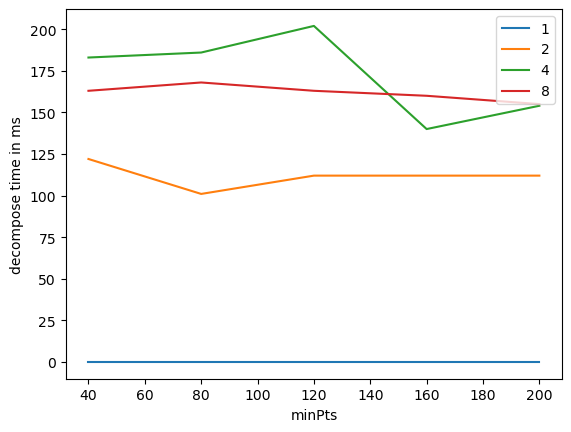

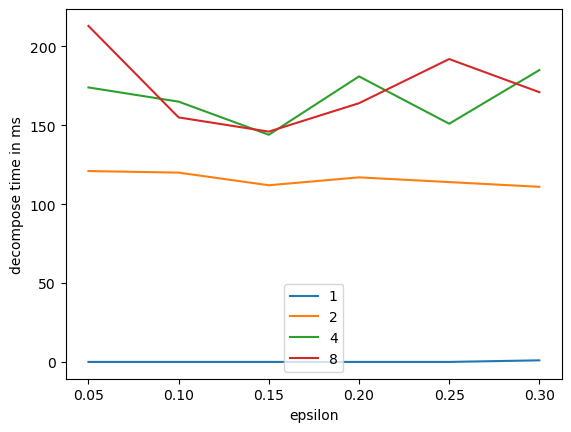

In [20]:
fig,ax = plt.subplots()
for num_proc in runtime_same_epsilon_df["numProcesses"].unique():
    proc_runtime_df = runtime_same_epsilon_df[runtime_same_epsilon_df["numProcesses"] == num_proc]
    ax.plot(proc_runtime_df["minPts"], proc_runtime_df["decomposeMs"], label=num_proc)
ax.set_xlabel("minPts")
ax.set_ylabel("decompose time in ms")
ax.legend()
plt.show()

fig,ax = plt.subplots()
for num_proc in runtime_same_minPts_df["numProcesses"].unique():
    proc_runtime_df = runtime_same_minPts_df[runtime_same_minPts_df["numProcesses"] == num_proc]
    ax.plot(proc_runtime_df["epsilon"], proc_runtime_df["decomposeMs"], label=num_proc)
ax.set_xlabel("epsilon")
ax.set_ylabel("decompose time in ms")
ax.legend()
plt.show()

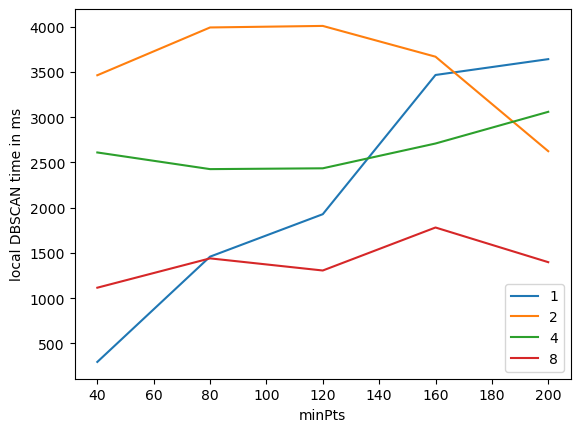

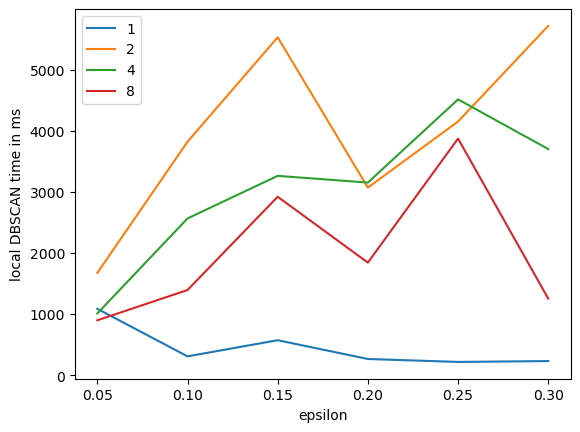

In [21]:
fig,ax = plt.subplots()
for num_proc in runtime_same_epsilon_df["numProcesses"].unique():
    proc_runtime_df = runtime_same_epsilon_df[runtime_same_epsilon_df["numProcesses"] == num_proc]
    ax.plot(proc_runtime_df["minPts"], proc_runtime_df["localDbscanMs"], label=num_proc)
ax.set_xlabel("minPts")
ax.set_ylabel("local DBSCAN time in ms")
ax.legend()
plt.show()

fig,ax = plt.subplots()
for num_proc in runtime_same_minPts_df["numProcesses"].unique():
    proc_runtime_df = runtime_same_minPts_df[runtime_same_minPts_df["numProcesses"] == num_proc]
    ax.plot(proc_runtime_df["epsilon"], proc_runtime_df["localDbscanMs"], label=num_proc)
ax.set_xlabel("epsilon")
ax.set_ylabel("local DBSCAN time in ms")
ax.legend()
plt.show()

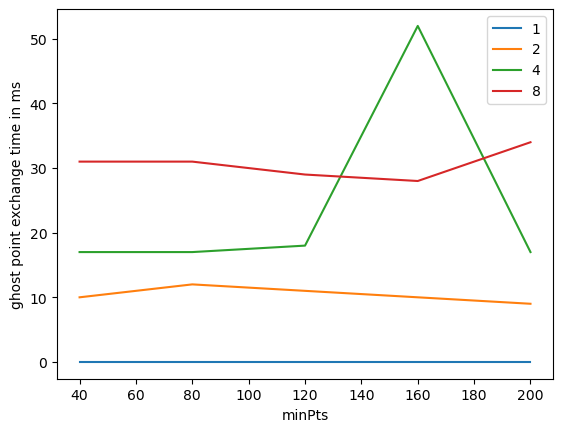

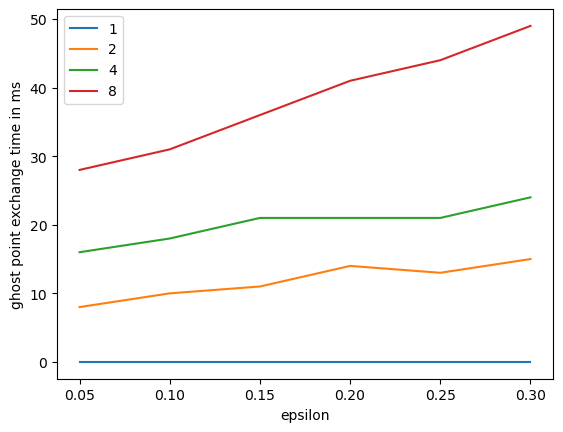

In [22]:
fig,ax = plt.subplots()
for num_proc in runtime_same_epsilon_df["numProcesses"].unique():
    proc_runtime_df = runtime_same_epsilon_df[runtime_same_epsilon_df["numProcesses"] == num_proc]
    ax.plot(proc_runtime_df["minPts"], proc_runtime_df["exchangeGhostPointsMs"], label=num_proc)
ax.set_xlabel("minPts")
ax.set_ylabel("ghost point exchange time in ms")
ax.legend()
plt.show()

fig,ax = plt.subplots()
for num_proc in runtime_same_minPts_df["numProcesses"].unique():
    proc_runtime_df = runtime_same_minPts_df[runtime_same_minPts_df["numProcesses"] == num_proc]
    ax.plot(proc_runtime_df["epsilon"], proc_runtime_df["exchangeGhostPointsMs"], label=num_proc)
ax.set_xlabel("epsilon")
ax.set_ylabel("ghost point exchange time in ms")
ax.legend()
plt.show()

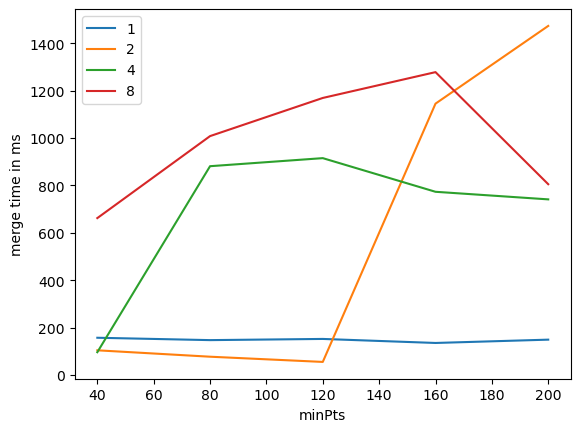

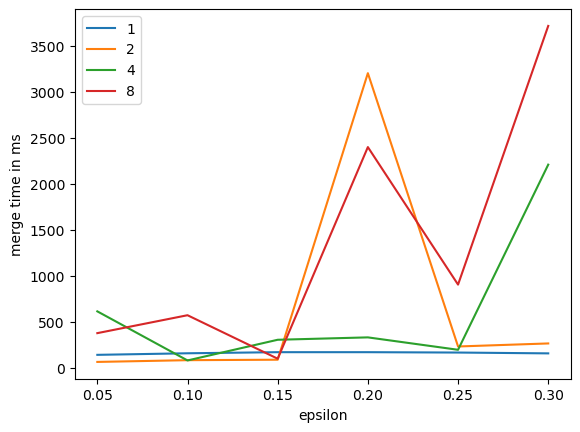

In [24]:
fig,ax = plt.subplots()
for num_proc in runtime_same_epsilon_df["numProcesses"].unique():
    proc_runtime_df = runtime_same_epsilon_df[runtime_same_epsilon_df["numProcesses"] == num_proc]
    ax.plot(proc_runtime_df["minPts"], proc_runtime_df["mergeMs"], label=num_proc)
ax.set_xlabel("minPts")
ax.set_ylabel("merge time in ms")
ax.legend()
plt.show()

fig,ax = plt.subplots()
for num_proc in runtime_same_minPts_df["numProcesses"].unique():
    proc_runtime_df = runtime_same_minPts_df[runtime_same_minPts_df["numProcesses"] == num_proc]
    ax.plot(proc_runtime_df["epsilon"], proc_runtime_df["mergeMs"], label=num_proc)
ax.set_xlabel("epsilon")
ax.set_ylabel("merge time in ms")
ax.legend()
plt.show()